# G2. Synthetic Data Generation

**Authors:** Ivo Rambaldi and Tommaso Petrelli

**Course:** Ethics in Artificial Intelligence, University of Bologna, a.y. 2025-2026

## What this notebook does

It takes the real training set from G1 and produces one synthetic replacement per generation
technique, then measures how closely each one resembles the original. Whether the result is
useful, and whether it is fair, is measured in G3 and G4.

## The four techniques

Gaussian copula (statistical), CTGAN and TVAE (deep generative), and SMOTE (oversampling).

The first three model the whole table and never condition on a target, so one run of each serves
both tasks. SMOTE rebalances whichever column is named as the target, so it runs once per task.
Four techniques, five datasets.

Hyperparameters are not tuned. The comparison is between the paradigms, and tuning one of them
would confound it.

## 1. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import check_prerequisites, get_logger, load_config, notebook_dirs, select_task
from src.utils.config import get_synthetic_output_path

warnings.filterwarnings("ignore", category=FutureWarning, module="sdv")
warnings.filterwarnings("ignore", category=UserWarning, module="sdv")

logger = get_logger("G2")
check_prerequisites()

cfg = select_task(load_config(PROJECT_ROOT / "config" / "config.yaml"), "high_perf")
RESULTS_DIR, FIGURES_DIR = notebook_dirs(cfg, "g2")

TARGETS = {name: task["column"] for name, task in cfg["tasks"].items()}

print(f"seed        : {cfg['seed']}")
print(f"targets     : {TARGETS}")
print(f"n synthetic : {cfg['generation']['n_synthetic_samples']} (null means match the training set)")

Prerequisites: 16 satisfied, 0 missing, 0 mismatched.
seed        : 42
targets     : {'high_perf': 'target_high_perf', 'low_perf': 'target_low_perf'}
n synthetic : None (null means match the training set)


## 2. Columns dropped before generation

Two groups of columns are removed. The performance scores, because both targets derive from
`score_MAT` and leaving it in would let any generator recover the label from the score. The
`_was_nan` flags, because a flag is a direct proxy for whether a circumstance was answered, and
G4 mitigates one circumstance at a time.

In [2]:
from src.data.loader import load_dataset

train_full = load_dataset(cfg["paths"]["train_data"], cfg, drop_id_columns=True)

drop = [c for c in cfg["dataset"]["performance_columns"] if c in train_full.columns]
drop += [c for c in train_full.columns if c.endswith("_was_nan")]
train_df = train_full.drop(columns=drop)

print(f"Loaded {train_full.shape}, dropped {len(drop)} columns, generating from {train_df.shape}")
for name, column in TARGETS.items():
    print(f"  {column}: {train_df[column].mean():.1%} positive")
print(f"  missing values present in {int((train_df.isna().sum() > 0).sum())} columns")

2026-08-01 18:52:45 | INFO     | src.data.loader | Loading dataset from C:\Users\tomma\Desktop\petrellirambaldi2526\Data\train.csv


2026-08-01 18:52:45 | INFO     | src.data.loader | Loaded 58128 rows and 50 columns


Loaded (58128, 50), dropped 10 columns, generating from (58128, 40)
  target_high_perf: 25.0% positive
  target_low_perf: 25.0% positive
  missing values present in 10 columns


## 3. Running the generators

The three model based generators share one metadata description of the table and one constraint,
which forbids a synthetic row from carrying both target labels at once.

All four techniques read the same rule for what counts as categorical: declared in the
configuration, holding text, or taking at most twenty distinct values. Without it a nine level
code such as `f_mother_education_level` would be interpolated into values like 3.42, which exist
nowhere in the real data. The shared rule is also what makes the four comparable.

In [3]:
from src.generation.metadata import build_metadata, categorical_columns

metadata = build_metadata(train_df, cfg)
synthetic = {}

print(f"{len(categorical_columns(train_df, cfg))} of {train_df.shape[1]} columns are categorical")

2026-08-01 18:52:53 | INFO     | src.generation.metadata | Metadata built: 26 categorical, 14 numerical columns


26 of 40 columns are categorical


### 3.1 CTGAN

In [4]:
from src.generation.ctgan_gen import generate_ctgan

synthetic["ctgan"] = generate_ctgan(
    train_df, metadata, cfg, get_synthetic_output_path(cfg, "ctgan"),
)

2026-08-01 18:52:57 | INFO     | src.generation.ctgan_gen | CTGAN: fitting on 58128 rows (epochs=300, batch_size=500, seed=42)


  0%|          | 0/300 [00:00<?, ?it/s]

Gen. (+00.00) | Discrim. (+00.00):   0%|          | 0/300 [00:00<?, ?it/s]

Gen. (-01.14) | Discrim. (+00.25):   0%|          | 0/300 [00:19<?, ?it/s]

Gen. (-01.14) | Discrim. (+00.25):   0%|          | 1/300 [00:19<1:38:53, 19.84s/it]

...

Gen. (-02.46) | Discrim. (+00.01): 100%|█████████▉| 299/300 [1:57:25<00:25, 25.00s/it]

Gen. (-02.46) | Discrim. (+00.01): 100%|██████████| 300/300 [1:57:25<00:00, 24.91s/it]

Gen. (-02.46) | Discrim. (+00.01): 100%|██████████| 300/300 [1:57:25<00:00, 23.48s/it]

2026-08-01 20:54:38 | INFO     | src.generation.ctgan_gen | CTGAN: sampling 58128 rows


2026-08-01 20:54:46 | INFO     | src.generation.io | CTGAN: saved 58128 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\ctgan\synthetic_ctgan.csv


### 3.2 TVAE

In [5]:
from src.generation.tvae_gen import generate_tvae

synthetic["tvae"] = generate_tvae(
    train_df, metadata, cfg, get_synthetic_output_path(cfg, "tvae"),
)

2026-08-01 20:54:46 | INFO     | src.generation.tvae_gen | TVAE: fitting on 58128 rows (epochs=300, batch_size=500, seed=42)


  0%|          | 0/300 [00:00<?, ?it/s]

Loss: +00.00:   0%|          | 0/300 [00:00<?, ?it/s]

Loss: +99.99:   0%|          | 0/300 [00:07<?, ?it/s]

Loss: +99.99:   0%|          | 1/300 [00:07<36:06,  7.24s/it]

...

Loss: +24.50: 100%|█████████▉| 299/300 [55:32<00:14, 14.94s/it]

Loss: +24.50: 100%|██████████| 300/300 [55:32<00:00, 14.99s/it]

Loss: +24.50: 100%|██████████| 300/300 [55:32<00:00, 11.11s/it]

2026-08-01 21:54:33 | INFO     | src.generation.tvae_gen | TVAE: sampling 58128 rows


2026-08-01 21:54:37 | INFO     | src.generation.io | TVAE: saved 58128 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\tvae\synthetic_tvae.csv


### 3.3 Gaussian copula

In [6]:
from src.generation.copula_gen import generate_gaussian_copula

synthetic["gaussian_copula"] = generate_gaussian_copula(
    train_df, metadata, cfg, get_synthetic_output_path(cfg, "gaussian_copula"),
)

2026-08-01 21:54:37 | INFO     | src.generation.copula_gen | GaussianCopula: fitting on 58128 rows


2026-08-01 21:55:52 | INFO     | src.generation.copula_gen | GaussianCopula: sampling 58128 rows


2026-08-01 21:56:06 | INFO     | src.generation.io | GaussianCopula: saved 58128 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\copula\synthetic_copula.csv


### 3.4 SMOTE

SMOTE oversamples the minority class of one column until the two classes are equal. Which column
that is changes the output, so the excellence run and the underperformance run produce two
different datasets. The output is larger than the training set, because SMOTE adds rows rather
than replacing them.

In [7]:
from src.generation.smote_gen import generate_smote

for task_name in cfg["tasks"]:
    task_cfg = select_task(cfg, task_name)
    method = "smote" if task_name == "high_perf" else "smote_low_perf"
    synthetic[method] = generate_smote(
        train_df, task_cfg, get_synthetic_output_path(task_cfg, method),
    )

2026-08-01 21:56:07 | INFO     | src.generation.smote_gen | SMOTE: fitting on 58128 rows (k_neighbors=5, seed=42)


2026-08-01 21:56:37 | INFO     | src.generation.smote_gen | SMOTE: 58128 original rows plus 29060 interpolated rows


2026-08-01 21:56:37 | INFO     | src.generation.smote_gen | Class balance: {0: 43594, 1: 43594}


2026-08-01 21:56:40 | INFO     | src.generation.io | SMOTE: saved 87188 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\smote\synthetic_smote.csv


2026-08-01 21:56:40 | INFO     | src.generation.smote_gen | SMOTE: fitting on 58128 rows (k_neighbors=5, seed=42)


2026-08-01 21:57:08 | INFO     | src.generation.smote_gen | SMOTE: 58128 original rows plus 29064 interpolated rows


2026-08-01 21:57:08 | INFO     | src.generation.smote_gen | Class balance: {0: 43596, 1: 43596}


2026-08-01 21:57:10 | INFO     | src.generation.io | SMOTE: saved 87192 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\smote_low_perf\synthetic_smote_low_perf.csv


## 4. The generated datasets

In [8]:
summary = []
for method, df in synthetic.items():
    row = {"method": method, "rows": len(df)}
    for name, column in TARGETS.items():
        row[f"{column} positive"] = f"{df[column].mean():.1%}"
    row["columns with missing"] = int((df.isna().sum() > 0).sum())
    summary.append(row)

real_row = {"method": "real", "rows": len(train_df)}
for name, column in TARGETS.items():
    real_row[f"{column} positive"] = f"{train_df[column].mean():.1%}"
real_row["columns with missing"] = int((train_df.isna().sum() > 0).sum())

print(pd.DataFrame([real_row] + summary).to_string(index=False))

         method  rows target_high_perf positive target_low_perf positive  columns with missing
           real 58128                     25.0%                    25.0%                    10
          ctgan 58128                     35.9%                    23.6%                    10
           tvae 58128                     17.7%                    27.0%                    10
gaussian_copula 58128                     25.1%                    25.0%                    10
          smote 87188                     50.0%                    16.7%                    10
 smote_low_perf 87192                     16.7%                    50.0%                    10


In [9]:
# The exclusivity constraint should hold in every generated dataset.
for method, df in synthetic.items():
    both = int((df[TARGETS["high_perf"]] & df[TARGETS["low_perf"]]).sum())
    print(f"  {method:<16} rows labelled as both tails: {both}")

  ctgan            rows labelled as both tails: 0
  tvae             rows labelled as both tails: 0
  gaussian_copula  rows labelled as both tails: 0
  smote            rows labelled as both tails: 0
  smote_low_perf   rows labelled as both tails: 0


**Observation.** No generator produced a row in both tails, so the constraint held. The three
model based generators aim at the real target rates, and the table shows how close each one gets.

Each SMOTE variant is balanced 50 to 50 on its own target by construction, which also pushes the
other target away from its real rate. That is what oversampling does, but it means the SMOTE rows
cannot be read as an attempt to reproduce the real distribution.

### 4.1 Missing values under SMOTE

SMOTE cannot represent a missing value. It interpolates between a point and its neighbours, and
interpolation returns a number, so the original rows keep their gaps and every row SMOTE adds is
complete.

G1 established that missingness in the family block tracks the households the questionnaire
failed to reach. Oversampling therefore dilutes the signal this project treats as ethically
meaningful, and does so as a side effect rather than as a stated choice.

In [10]:
from src.generation.smote_gen import missingness_comparison

comparison = missingness_comparison(train_df, synthetic["smote"])
print(comparison.apply(lambda c: c.map("{:.1%}".format)).to_string())

                                                    real synthetic difference
s_birth_country                                    78.4%     52.3%     -26.1%
f_frequency_of_see_adult_read                      35.5%     23.7%     -11.8%
f_father_occupation                                34.7%     23.2%     -11.6%
f_father_education_level                           32.7%     21.8%     -10.9%
f_mother_occupation                                30.7%     20.5%     -10.2%
f_mother_education_level                           27.8%     18.5%      -9.3%
f_start_schooling_age                              27.1%     18.1%      -9.0%
f_ESCS                                             26.3%     17.5%      -8.8%
f_extent_of_books_at_home                          25.8%     17.2%      -8.6%
p_percentage_of_teachers_changed_school_last_year   5.7%      3.8%      -1.9%


## 5. Fidelity

- MMD is the distance between the real and the synthetic numerical columns as whole
  distributions. Its kernel width is set from the data it is given, so the values rank the
  generators against each other and do not transfer across sections.
- Correlation MAE measures how far the rank correlations between columns have moved.
- KL divergence measures, per categorical column, how far the category frequencies have moved.

Fidelity is not utility. A dataset can look right and still train a useless classifier, which is
what G3 tests.

In [11]:
from src.generation.fidelity import compute_fidelity_report, fidelity_table, kl_table

reports = {
    method: compute_fidelity_report(train_df, df, cfg, method)
    for method, df in synthetic.items()
}
table = fidelity_table(reports)
print(table.round(6).to_string(index=False))

2026-08-01 21:57:10 | INFO     | src.generation.fidelity | Fidelity report for ctgan


2026-08-01 21:57:12 | INFO     | src.generation.fidelity |   MMD=0.002984 corr_MAE=0.0908 mean_KL=0.0193


2026-08-01 21:57:12 | INFO     | src.generation.fidelity | Fidelity report for tvae


2026-08-01 21:57:15 | INFO     | src.generation.fidelity |   MMD=0.001954 corr_MAE=0.0682 mean_KL=0.0833


2026-08-01 21:57:15 | INFO     | src.generation.fidelity | Fidelity report for gaussian_copula


...

2026-08-01 21:57:17 | INFO     | src.generation.fidelity | Fidelity report for smote


2026-08-01 21:57:19 | INFO     | src.generation.fidelity |   MMD=0.000164 corr_MAE=0.0063 mean_KL=0.0218


2026-08-01 21:57:19 | INFO     | src.generation.fidelity | Fidelity report for smote_low_perf


2026-08-01 21:57:21 | INFO     | src.generation.fidelity |   MMD=0.000000 corr_MAE=0.0085 mean_KL=0.0286


         method  n_synthetic      mmd  correlation_mae  mean_kl
          ctgan        58128 0.002984         0.090795 0.019256
           tvae        58128 0.001954         0.068173 0.083297
gaussian_copula        58128 0.009884         0.025300 0.000503
          smote        87188 0.000164         0.006306 0.021813
 smote_low_perf        87192 0.000000         0.008504 0.028572


2026-08-01 21:57:22 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g2\fidelity_summary.png


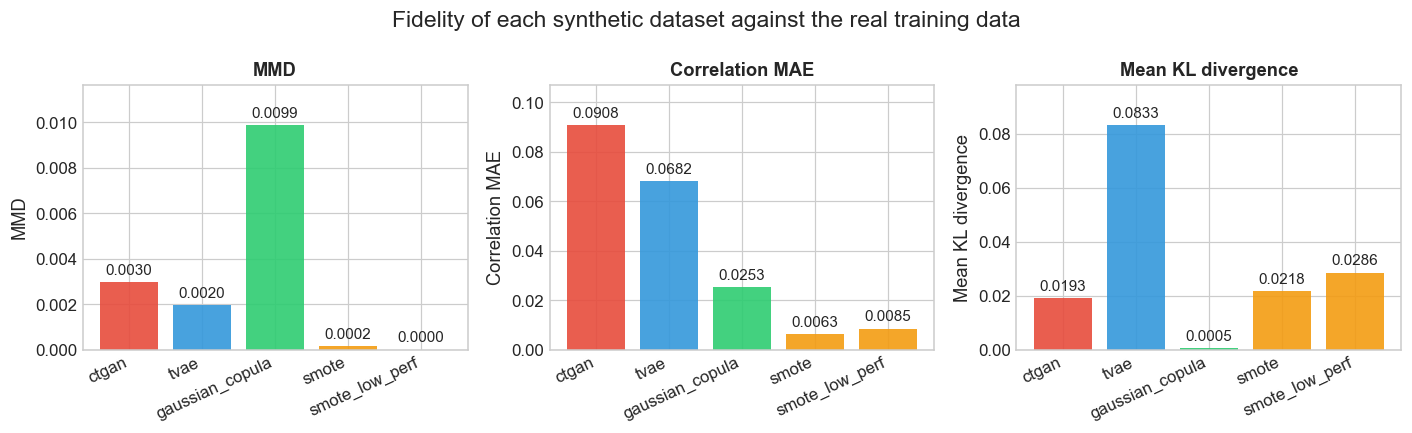

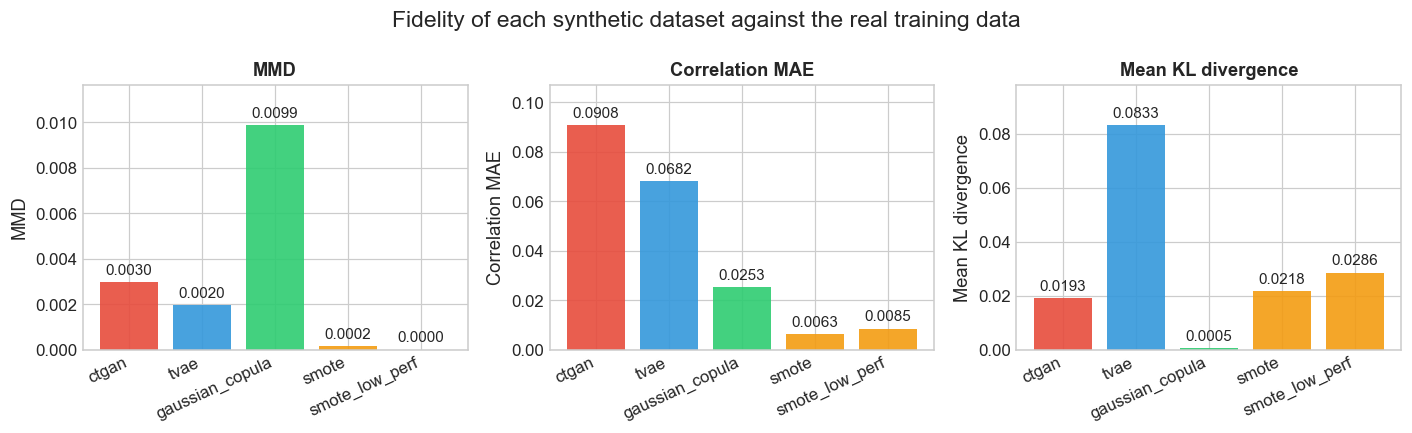

In [12]:
from src.utils.plotting import plot_fidelity_summary

plot_fidelity_summary(table, FIGURES_DIR)

### 5.1 KL divergence on the protected attributes

If a generator moves the frequency of a circumstance, it moves the group sizes that the fairness
metrics in G3 are built on.

In [13]:
from src.generation.metadata import categorical_columns

categorical_protected = [
    c for c in cfg["dataset"]["protected_attributes"]
    if c in set(categorical_columns(train_df, cfg))
]
protected_kl = kl_table(reports, categorical_protected + list(TARGETS.values()))
print("KL divergence, real against synthetic, lower is better:")
print(protected_kl.round(4).to_string())

KL divergence, real against synthetic, lower is better:
                                                    ctgan    tvae  gaussian_copula   smote  smote_low_perf
s_gender                                           0.0007  0.0387           0.0000  0.0008          0.0001
f_mother_education_level                           0.0375  0.0624           0.0001  0.0495          0.0805
f_father_education_level                           0.0221  0.0377           0.0001  0.0684          0.1035
f_mother_occupation                                0.0054  0.0422           0.0001  0.0269          0.0434
f_father_occupation                                0.0096  0.0115           0.0001  0.0269          0.0543
s_birth_country                                    0.0804  0.1851           0.0118  0.0429          0.0417
f_start_schooling_age                              0.0117  0.0357           0.0000  0.0288          0.0160
f_extent_of_books_at_home                          0.0356  0.0139           0.0000  0.02

## 6. Marginal distributions

2026-08-01 21:57:23 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g2\class_balance_target_high_perf.png


2026-08-01 21:57:23 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g2\class_balance_target_low_perf.png


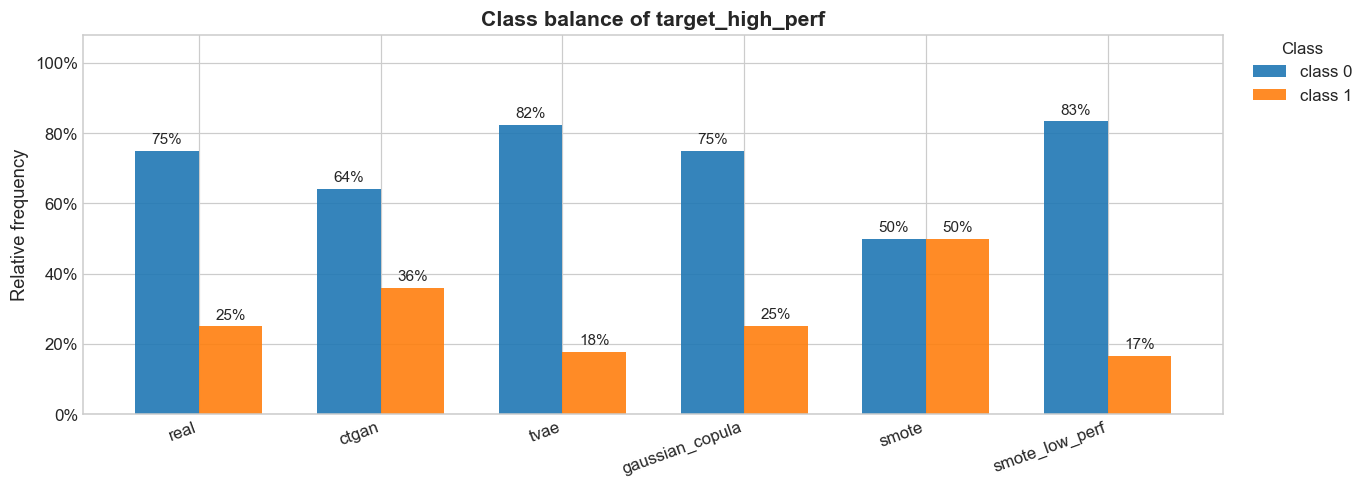

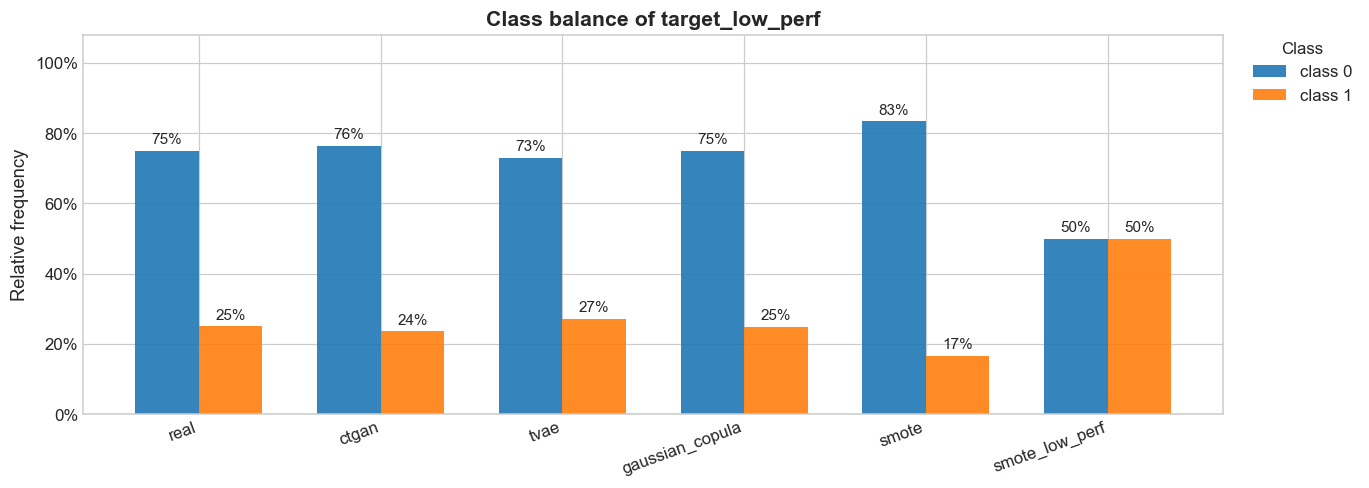

In [14]:
from src.utils.plotting import plot_class_balance, plot_marginal_distributions

for name, column in TARGETS.items():
    plot_class_balance(train_df, synthetic, column, FIGURES_DIR)

2026-08-01 21:57:24 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g2\marginal_target_high_perf.png


2026-08-01 21:57:25 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g2\marginal_target_low_perf.png


2026-08-01 21:57:25 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g2\marginal_s_gender.png


2026-08-01 21:57:26 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g2\marginal_f_ESCS.png


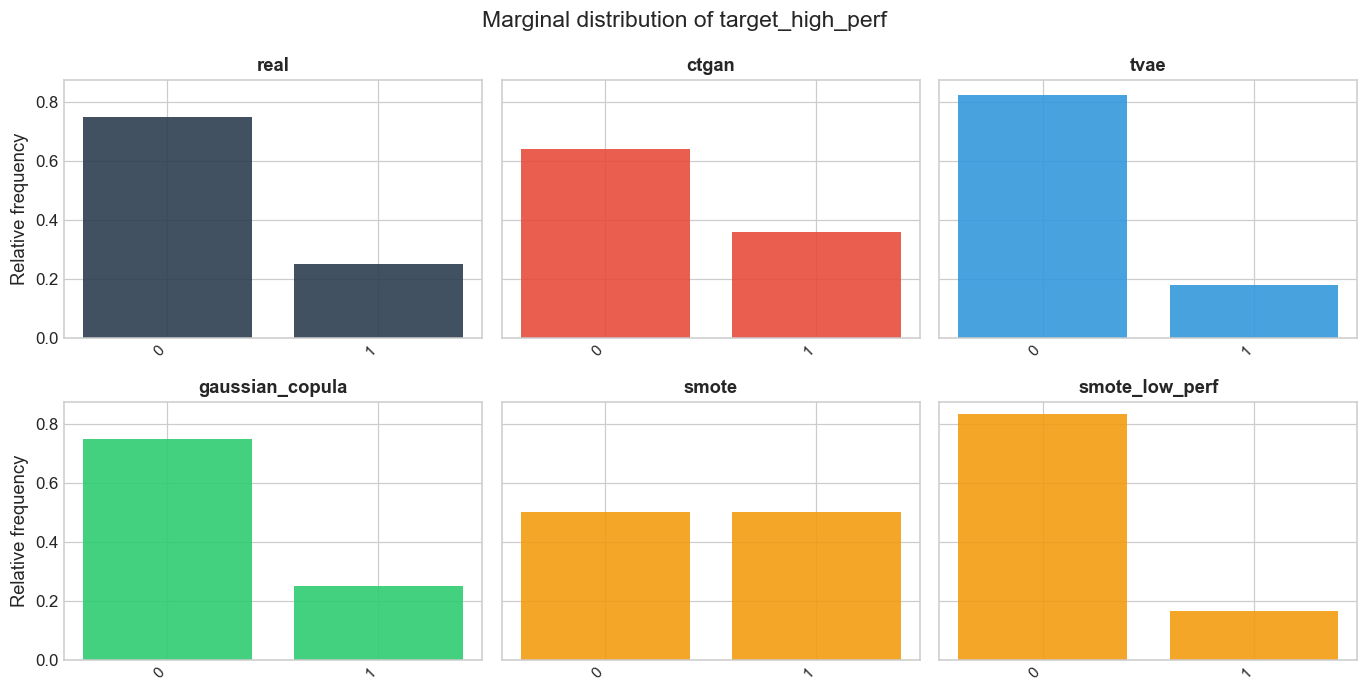

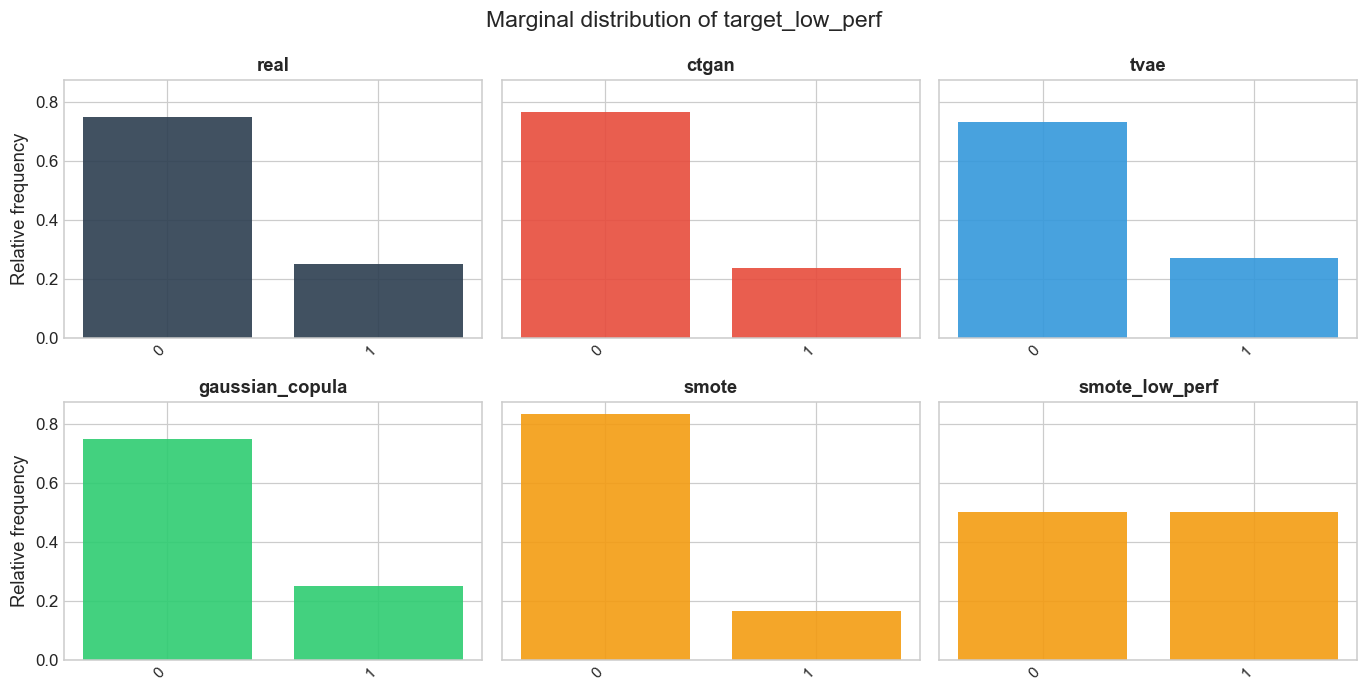

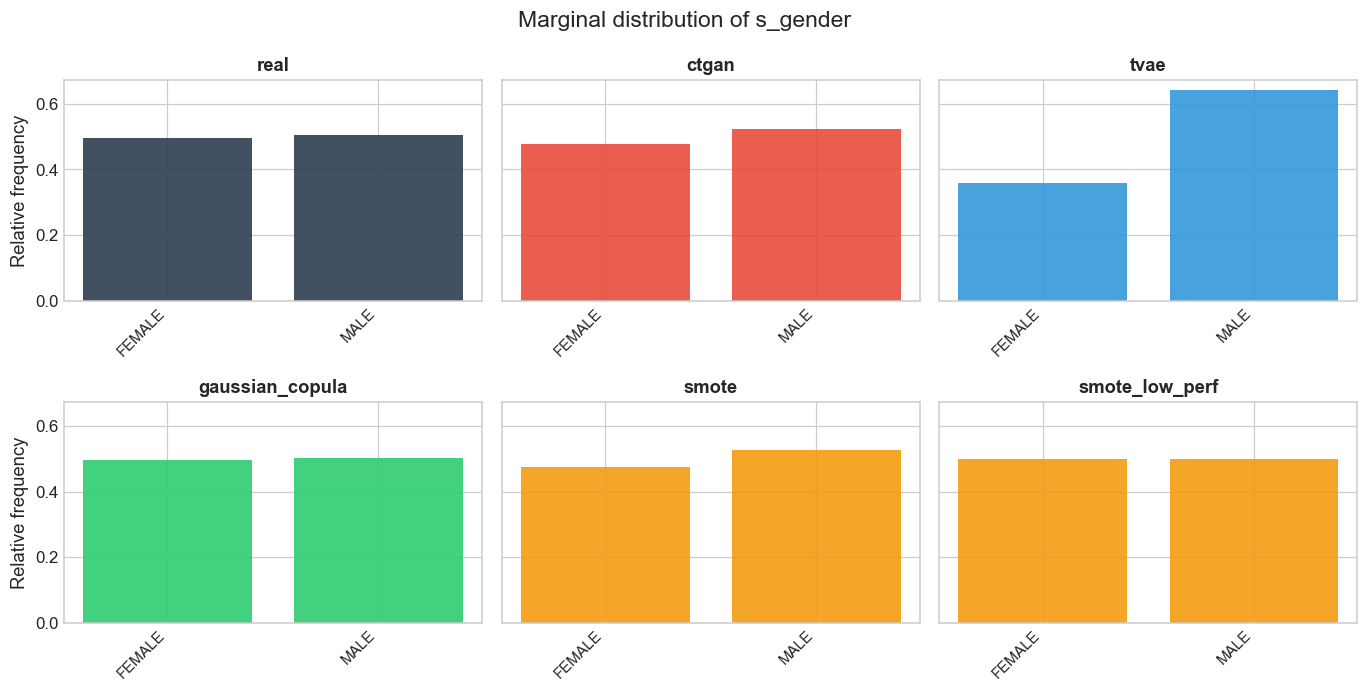

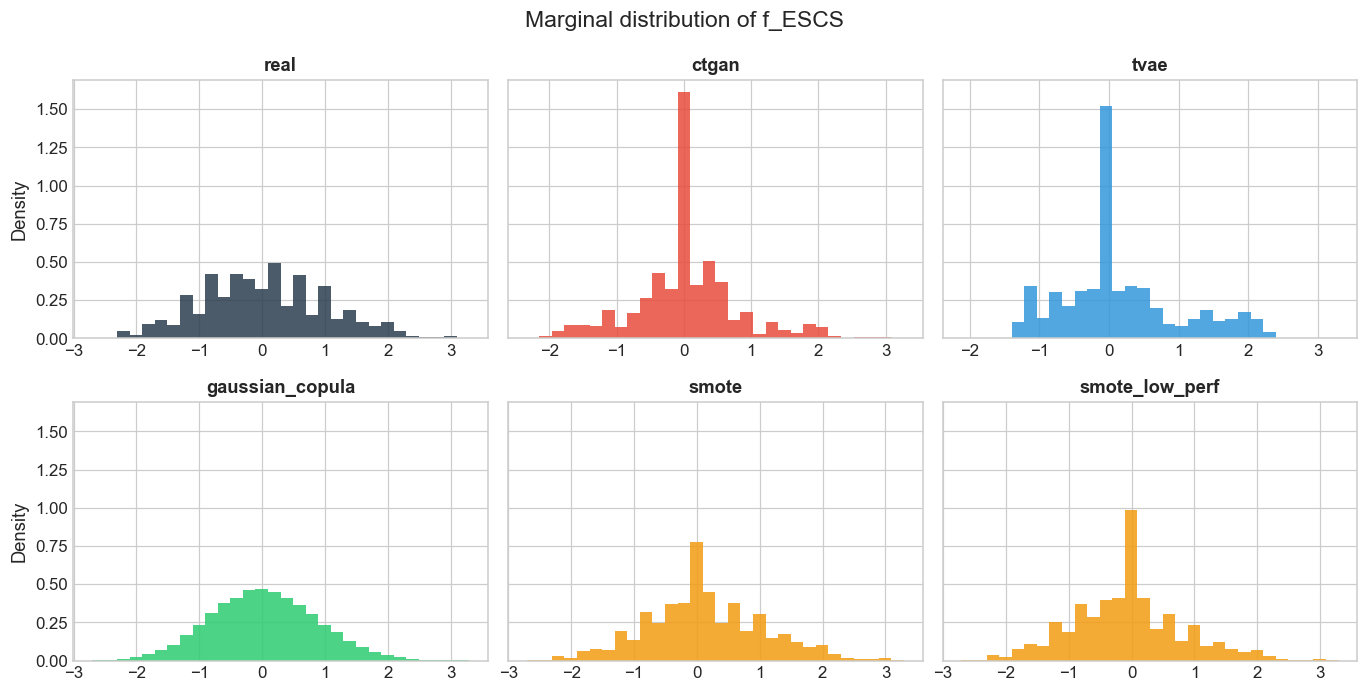

In [15]:
for column in list(TARGETS.values()) + ["s_gender", "f_ESCS"]:
    plot_marginal_distributions(train_df, synthetic, column, cfg, FIGURES_DIR)

## 7. Composition of the minority class under SMOTE

SMOTE creates rows only for the minority class, interpolating between its members and their
nearest neighbours, so the new rows resemble its dense centre rather than its edges.

That is worth checking on both variants, because the minority class is a different population in
each: the top quarter, which skews advantaged, and the bottom quarter, which skews disadvantaged.

In [16]:
def minority_shift(real_df, smote_df, target, attributes):
    """How the composition of the minority class changes once SMOTE has filled it in."""
    rows = []
    for attr in attributes:
        real_share = real_df.loc[real_df[target] == 1, attr].value_counts(normalize=True)
        smote_share = smote_df.loc[smote_df[target] == 1, attr].value_counts(normalize=True)
        for value in real_share.index:
            rows.append({
                "attribute": attr,
                "value": value,
                "real": real_share.get(value, 0.0),
                "smote": smote_share.get(value, 0.0),
            })
    out = pd.DataFrame(rows)
    out["shift"] = out["smote"] - out["real"]
    return out.reindex(out["shift"].abs().sort_values(ascending=False).index)


attributes = ["f_mother_education_level", "f_father_occupation", "f_extent_of_books_at_home", "s_gender"]

for task_name, method in [("high_perf", "smote"), ("low_perf", "smote_low_perf")]:
    target = TARGETS[task_name]
    print(f"\n{method}, largest shifts inside the minority class of {target}:")
    print(minority_shift(train_df, synthetic[method], target, attributes)
          .head(8).round(3).to_string(index=False))


smote, largest shifts inside the minority class of target_high_perf:
                attribute value  real  smote  shift
 f_mother_education_level   4.0 0.242  0.494  0.252
f_extent_of_books_at_home  0.25 0.340  0.566  0.226
      f_father_occupation   3.0 0.554  0.746  0.192
      f_father_occupation   4.0 0.332  0.210 -0.122
f_extent_of_books_at_home   0.5 0.249  0.180 -0.069
      f_father_occupation   2.0 0.109  0.043 -0.067
f_extent_of_books_at_home  0.75 0.154  0.096 -0.058
 f_mother_education_level   3.0 0.160  0.108 -0.051

smote_low_perf, largest shifts inside the minority class of target_low_perf:
                attribute value  real  smote  shift
 f_mother_education_level   4.0 0.260  0.599  0.340
f_extent_of_books_at_home  0.25 0.440  0.717  0.277
      f_father_occupation   3.0 0.598  0.859  0.262
      f_father_occupation   2.0 0.196  0.069 -0.127
      f_father_occupation   4.0 0.191  0.068 -0.123
f_extent_of_books_at_home   0.0 0.250  0.141 -0.109
 f_mother_education_

**Observation.** The shifts are shares of the students who answered, so a positive shift means a
category grew relative to the other answers, not that more students gave it.

Two mechanisms push the same way: SMOTENC gives a new row the most common value among its
neighbours, and a blank answer is filled with the column mode before the neighbour search. The
direction is towards the modal category, which is not the same as towards advantage, since the
highest occupation category loses ground even though it is the privileged one.

G3 and G4 then measure group differences on a distribution where the smallest groups have been
compressed towards the middle.

## 8. Final observations

- The exclusivity constraint held everywhere, so both tasks can be evaluated on the same
  synthetic files without contradiction.
- The generators differ in how faithfully they preserve the target rates, so part of what G3
  measures as a utility loss is a change in prevalence rather than a change in signal.
- Good fidelity is not good utility. These numbers say only that the tables resemble each other.
- SMOTE removes missingness from the rows it creates and concentrates the minority class on its
  most common categories. Both effects push against what G1 established about who is missing.